In [2]:
# ── Cell 1: Load and merge all model results ─────────────────────────────────
import pandas as pd
import numpy as np

# Load XGBoost + baselines
df_xgb = pd.read_csv("data/model_comparison_results.csv")

# Load LSTM results and reshape to flat comparison format
df_lstm_raw = pd.read_csv("lstm/two_stage_lstm_comparison.csv")

lstm_rows = []
for _, row in df_lstm_raw.iterrows():
    lstm_rows.append({
        "Model": f"LSTM {row['Variant']} ({int(row['Features'])} features)",
        "RMSE (mm)": row["Combined_RMSE"],
        "MAE (mm)":  row["Combined_MAE"],
        "R²":        row["Combined_R2"],
        "Type":      "LSTM"
    })

df_lstm = pd.DataFrame(lstm_rows)

# Combine into master comparison table
df_all = pd.concat([df_xgb, df_lstm], ignore_index=True)

# Rank by RMSE (lower is better)
df_all["RMSE_Rank"] = df_all["RMSE (mm)"].rank().astype(int)

print(df_all.to_string(index=False))
df_all.to_csv("comparison/full_model_comparison.csv", index=False)
print("\nSaved → comparison/full_model_comparison.csv")


                      Model  RMSE (mm)  MAE (mm)        R²     Type  RMSE_Rank
          Two-Stage XGBoost  12.580637  6.426565  0.196298 ML Model          3
                Persistence  14.797521  6.761782 -0.111906 Baseline          5
                Climatology  15.193564  8.487765 -0.172221 Baseline          6
            Rolling Average  15.935254  7.465397 -0.289460 Baseline          7
  LSTM Minimal (8 features)  12.198196  5.900571  0.243150     LSTM          1
LSTM Enhanced (26 features)  13.217242  6.107960  0.111412     LSTM          4
    LSTM Full (71 features)  12.540831  6.430429  0.200034     LSTM          2

Saved → comparison/full_model_comparison.csv


In [3]:
# ── Cell 2: Formatted summary table with highlights ──────────────────────────
from IPython.display import display

# Define display order: baselines first, then ML models
order = ["Persistence", "Climatology", "Rolling Average",
         "Two-Stage XGBoost",
         "LSTM Minimal (8 features)",
         "LSTM Enhanced (26 features)",
         "LSTM Full (71 features)"]

df_display = df_all.set_index("Model").reindex(order).reset_index()

# Format numeric columns
df_display["RMSE (mm)"] = df_display["RMSE (mm)"].map("{:.4f}".format)
df_display["MAE (mm)"]  = df_display["MAE (mm)"].map("{:.4f}".format)
df_display["R²"]        = df_display["R²"].map("{:.4f}".format)

display(df_display[["Model", "Type", "RMSE (mm)", "MAE (mm)", "R²", "RMSE_Rank"]])


,Model,Type,RMSE (mm),MAE (mm),R²,RMSE_Rank
0,Persistence,Baseline,14.7975,6.7618,-0.1119,5
1,Climatology,Baseline,15.1936,8.4878,-0.1722,6
2,Rolling Average,Baseline,15.9353,7.4654,-0.2895,7
3,Two-Stage XGBoost,ML Model,12.5806,6.4266,0.1963,3
4,LSTM Minimal (8 features),LSTM,12.1982,5.9006,0.2431,1
5,LSTM Enhanced (26 features),LSTM,13.2172,6.1080,0.1114,4
6,LSTM Full (71 features),LSTM,12.5408,6.4304,0.2000,2


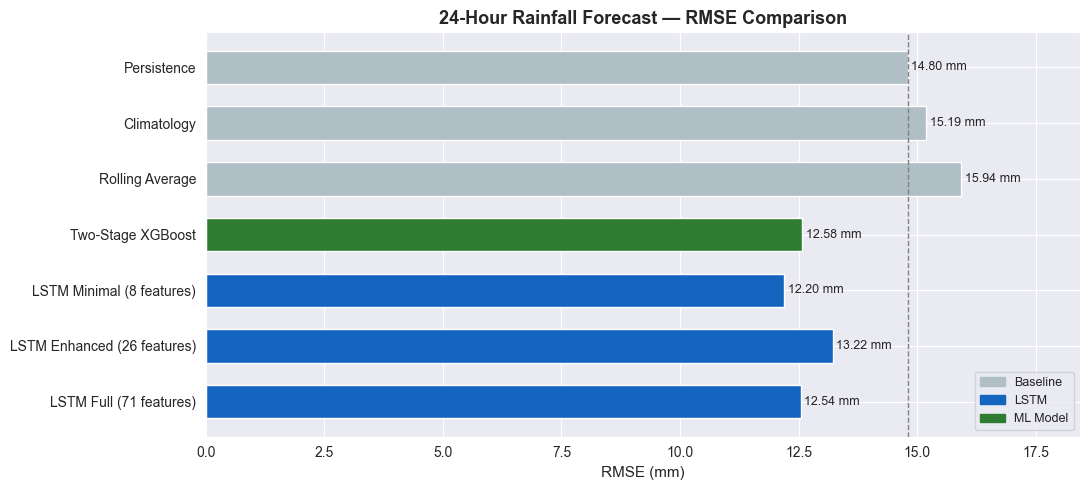

Saved → comparison/comparison_rmse_bar.png


In [4]:
# ── Cell 3: RMSE comparison bar chart ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLORS = {
    "Baseline": "#B0BEC5",
    "LSTM":     "#1565C0",
    "ML Model": "#2E7D32"
}

df_plot = df_all.set_index("Model").reindex(order).reset_index()
colors  = [COLORS[t] for t in df_plot["Type"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df_plot["Model"], df_plot["RMSE (mm)"], color=colors, edgecolor="white", height=0.6)

# Value labels
for bar, val in zip(bars, df_plot["RMSE (mm)"]):
    ax.text(bar.get_width() + 0.08, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f} mm", va="center", ha="left", fontsize=9)

ax.set_xlabel("RMSE (mm)", fontsize=11)
ax.set_title("24-Hour Rainfall Forecast — RMSE Comparison", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, df_plot["RMSE (mm)"].max() + 2.5)
ax.axvline(df_plot.loc[df_plot["Type"] == "Baseline", "RMSE (mm)"].min(),
           color="grey", linestyle="--", linewidth=1, label="Best baseline")

legend_handles = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("comparison/comparison_rmse_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison/comparison_rmse_bar.png")


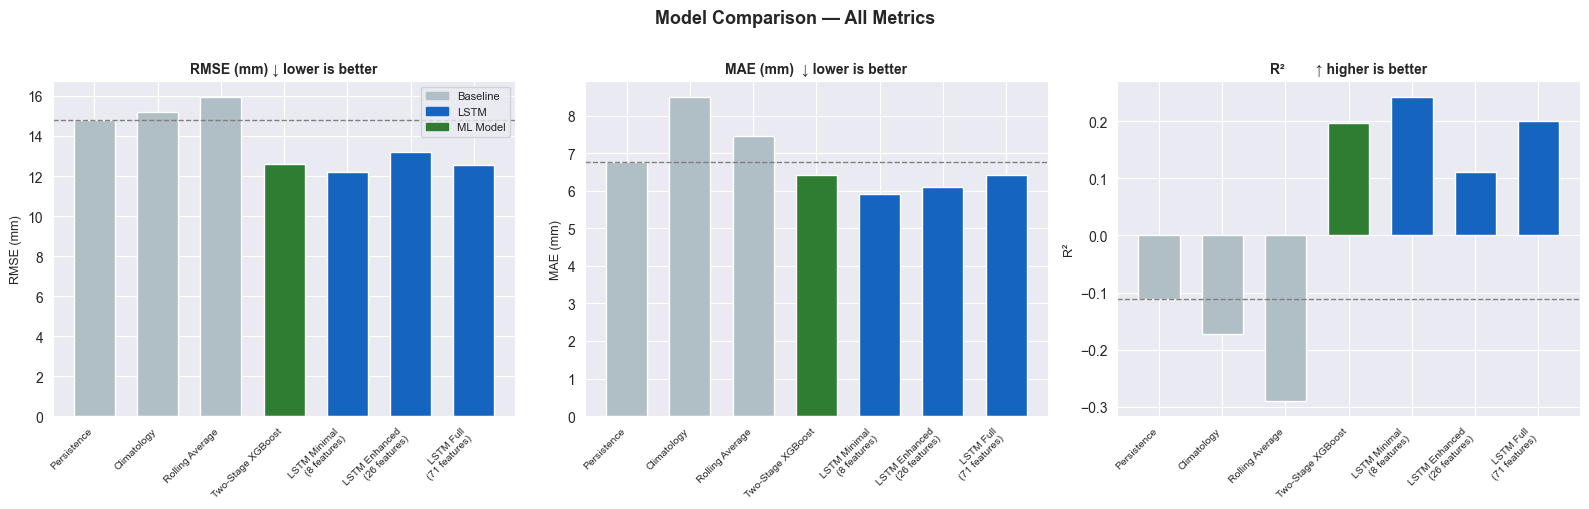

Saved → comparison/comparison_all_metrics.png


In [5]:
# ── Cell 4: Multi-metric grouped bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["RMSE (mm)", "MAE (mm)", "R²"]
titles  = ["RMSE (mm) ↓ lower is better",
           "MAE (mm)  ↓ lower is better",
           "R²        ↑ higher is better"]

df_plot = df_all.set_index("Model").reindex(order).reset_index()
x      = range(len(df_plot))
colors = [COLORS[t] for t in df_plot["Type"]]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(x, df_plot[metric], color=colors, edgecolor="white", width=0.65)
    ax.set_xticks(list(x))
    ax.set_xticklabels([m.replace(" (", "\n(") for m in df_plot["Model"]],
                       rotation=45, ha="right", fontsize=7.5)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(metric, fontsize=9)
    # Horizontal reference line at best baseline
    if metric in ["RMSE (mm)", "MAE (mm)"]:
        ref = df_plot.loc[df_plot["Type"] == "Baseline", metric].min()
        ax.axhline(ref, color="grey", linestyle="--", linewidth=1)
    else:
        ref = df_plot.loc[df_plot["Type"] == "Baseline", metric].max()
        ax.axhline(ref, color="grey", linestyle="--", linewidth=1)

legend_handles = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
axes[0].legend(handles=legend_handles, fontsize=8)

plt.suptitle("Model Comparison — All Metrics", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("comparison/comparison_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison/comparison_all_metrics.png")


In [6]:
# ── Cell 5: % improvement over best baseline (Persistence) ───────────────────
baseline_rmse = df_all.loc[df_all["Model"] == "Persistence", "RMSE (mm)"].values[0]
baseline_mae  = df_all.loc[df_all["Model"] == "Persistence", "MAE (mm)"].values[0]

df_imp = df_all[df_all["Type"] != "Baseline"].copy()
df_imp["RMSE_Improvement_%"] = ((baseline_rmse - df_imp["RMSE (mm)"]) / baseline_rmse * 100).round(2)
df_imp["MAE_Improvement_%"]  = ((baseline_mae  - df_imp["MAE (mm)"])  / baseline_mae  * 100).round(2)

print("Improvement over Persistence baseline:\n")
print(df_imp[["Model", "RMSE (mm)", "RMSE_Improvement_%", "MAE (mm)", "MAE_Improvement_%"]].to_string(index=False))


Improvement over Persistence baseline:

                      Model  RMSE (mm)  RMSE_Improvement_%  MAE (mm)  MAE_Improvement_%
          Two-Stage XGBoost  12.580637               14.98  6.426565               4.96
  LSTM Minimal (8 features)  12.198196               17.57  5.900571              12.74
LSTM Enhanced (26 features)  13.217242               10.68  6.107960               9.67
    LSTM Full (71 features)  12.540831               15.25  6.430429               4.90


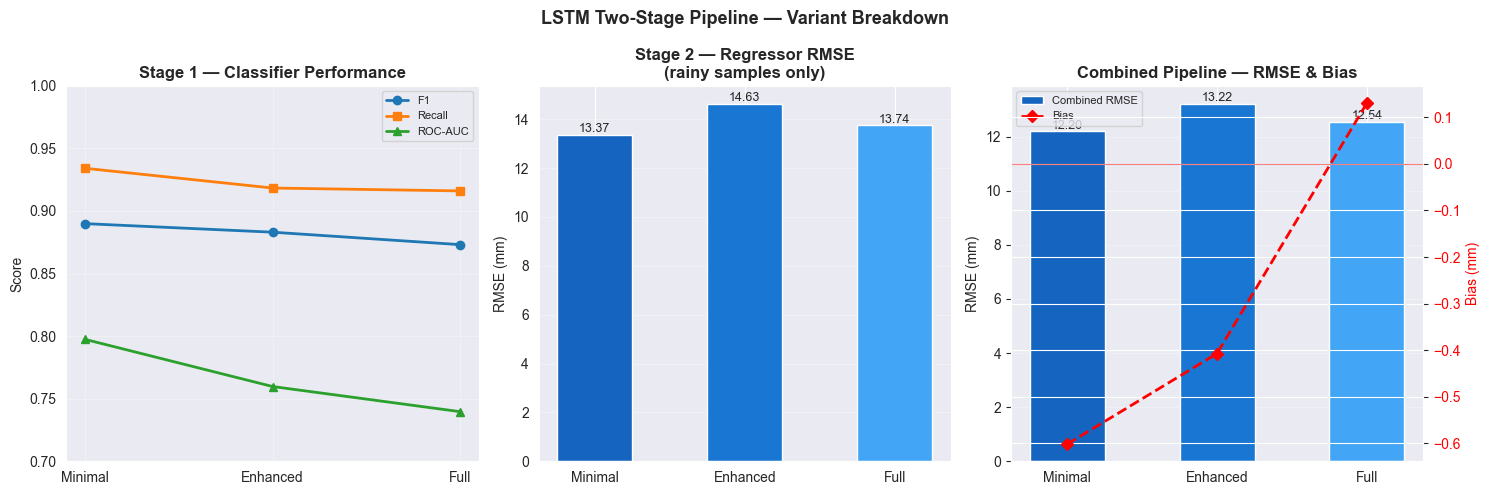

Saved → comparison/lstm_variant_breakdown.png


In [7]:
# ── Cell 6: LSTM stage-level metrics across variants ─────────────────────────
df_lstm_raw = pd.read_csv("lstm/two_stage_lstm_comparison.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
variants = df_lstm_raw["Variant"].tolist()
x = range(len(variants))

# Stage 1 — Classification metrics
ax = axes[0]
ax.plot(x, df_lstm_raw["Stage1_F1"],      marker="o", label="F1",      linewidth=2)
ax.plot(x, df_lstm_raw["Stage1_Recall"],  marker="s", label="Recall",  linewidth=2)
ax.plot(x, df_lstm_raw["Stage1_ROC_AUC"], marker="^", label="ROC-AUC", linewidth=2)
ax.set_xticks(list(x)); ax.set_xticklabels(variants)
ax.set_ylim(0.7, 1.0)
ax.set_title("Stage 1 — Classifier Performance", fontweight="bold")
ax.set_ylabel("Score"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Stage 2 — Regressor RMSE (rainy samples only)
ax = axes[1]
ax.bar(x, df_lstm_raw["Stage2_RMSE"], color=["#1565C0", "#1976D2", "#42A5F5"],
       edgecolor="white", width=0.5)
ax.set_xticks(list(x)); ax.set_xticklabels(variants)
ax.set_title("Stage 2 — Regressor RMSE\n(rainy samples only)", fontweight="bold")
ax.set_ylabel("RMSE (mm)"); ax.grid(alpha=0.3, axis="y")
for i, v in enumerate(df_lstm_raw["Stage2_RMSE"]):
    ax.text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=9)

# Combined pipeline RMSE + Bias
ax = axes[2]
ax2 = ax.twinx()
bars = ax.bar(x, df_lstm_raw["Combined_RMSE"], color=["#1565C0", "#1976D2", "#42A5F5"],
              edgecolor="white", width=0.5, label="Combined RMSE")
ax2.plot(x, df_lstm_raw["Combined_Bias"], color="red", marker="D",
         linestyle="--", linewidth=2, label="Bias")
ax2.axhline(0, color="red", linewidth=0.8, alpha=0.5)
ax.set_xticks(list(x)); ax.set_xticklabels(variants)
ax.set_title("Combined Pipeline — RMSE & Bias", fontweight="bold")
ax.set_ylabel("RMSE (mm)"); ax2.set_ylabel("Bias (mm)", color="red")
ax2.tick_params(axis="y", labelcolor="red")
for i, v in enumerate(df_lstm_raw["Combined_RMSE"]):
    ax.text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=9)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8)
ax.grid(alpha=0.3, axis="y")

plt.suptitle("LSTM Two-Stage Pipeline — Variant Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison/lstm_variant_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison/lstm_variant_breakdown.png")


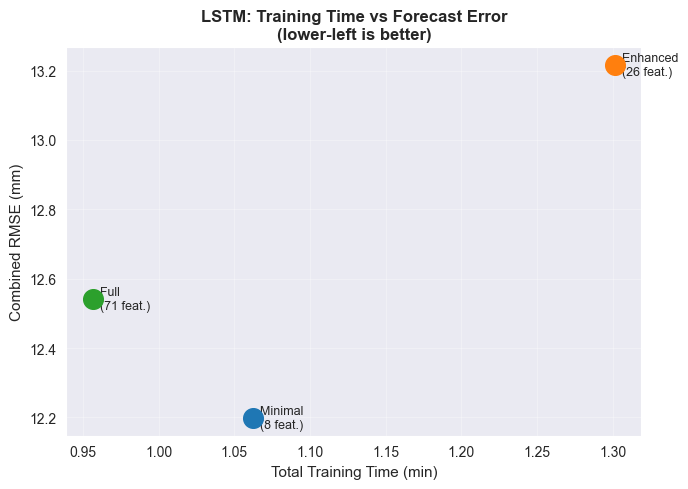

Saved → comparison/lstm_time_vs_rmse.png


In [8]:
# ── Cell 7: Training time vs RMSE scatter (LSTM variants) ────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for _, row in df_lstm_raw.iterrows():
    ax.scatter(row["Total_Training_Time_min"], row["Combined_RMSE"],
               s=200, zorder=5)
    ax.annotate(f"  {row['Variant']}\n  ({int(row['Features'])} feat.)",
                (row["Total_Training_Time_min"], row["Combined_RMSE"]),
                fontsize=9, va="center")

ax.set_xlabel("Total Training Time (min)", fontsize=11)
ax.set_ylabel("Combined RMSE (mm)", fontsize=11)
ax.set_title("LSTM: Training Time vs Forecast Error\n(lower-left is better)",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison/lstm_time_vs_rmse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison/lstm_time_vs_rmse.png")


In [9]:
# ── Cell 8: Clean thesis-ready comparison table ──────────────────────────────
thesis_order = [
    "Persistence", "Climatology", "Rolling Average",
    "Two-Stage XGBoost",
    "LSTM Minimal (8 features)",
    "LSTM Enhanced (26 features)",
    "LSTM Full (71 features)"
]

df_thesis = df_all.set_index("Model").reindex(thesis_order).reset_index()
df_thesis["Δ RMSE vs Persistence"] = (
    df_thesis["RMSE (mm)"] - df_all.loc[df_all["Model"] == "Persistence", "RMSE (mm)"].values[0]
).map("{:+.3f}".format)

df_thesis["RMSE (mm)"] = df_thesis["RMSE (mm)"].map("{:.3f}".format)
df_thesis["MAE (mm)"]  = df_thesis["MAE (mm)"].map("{:.3f}".format)
df_thesis["R²"]        = df_thesis["R²"].map("{:.3f}".format)

print("=" * 75)
print("THESIS TABLE — 24-Hour Rainfall Forecast Model Comparison (Test Set)")
print("=" * 75)
print(df_thesis[["Model", "Type", "RMSE (mm)", "MAE (mm)", "R²",
                 "Δ RMSE vs Persistence"]].to_string(index=False))
print("=" * 75)
print("Note: Test period = 2024-10-01 to 2025-12-31 | Classification threshold = 1.0 mm")


THESIS TABLE — 24-Hour Rainfall Forecast Model Comparison (Test Set)
                      Model     Type RMSE (mm) MAE (mm)     R² Δ RMSE vs Persistence
                Persistence Baseline    14.798    6.762 -0.112                +0.000
                Climatology Baseline    15.194    8.488 -0.172                +0.396
            Rolling Average Baseline    15.935    7.465 -0.289                +1.138
          Two-Stage XGBoost ML Model    12.581    6.427  0.196                -2.217
  LSTM Minimal (8 features)     LSTM    12.198    5.901  0.243                -2.599
LSTM Enhanced (26 features)     LSTM    13.217    6.108  0.111                -1.580
    LSTM Full (71 features)     LSTM    12.541    6.430  0.200                -2.257
Note: Test period = 2024-10-01 to 2025-12-31 | Classification threshold = 1.0 mm
